# SCX + scanpy tutorial: end-to-end single-cell workflow with Harmony2 integration

This notebook walks through a **standard scanpy analysis pipeline** on a
~85k-cell slice of Tabula Sapiens (blood, multiple donors + assays — an
ideal test case for batch integration), using the **SCX accelerators**
(`pyscx.accel.*`) as drop-in replacements for the usual `scanpy.tl.*` /
`scanpy.pp.*` calls, plus the Rust-native **Harmony2** port for
batch-effect correction.

Steps:

1. Download a small CELLxGENE census slice (~85k cells × 60k genes)
2. Convert the h5ad to the **SCX** binary format
3. Open the `.scx` file as a **backed** `AnnData` (streaming, low memory)
4. QC metrics, cell / gene filtering (non-materializing)
5. Lazy `normalize_total` + `log1p` (fused, no copy)
6. Highly variable gene selection (`seurat_v3`)
7. PCA (streaming randomized SVD)
8. kNN graph + UMAP **before** Harmony (for side-by-side comparison)
9. **Harmony2** batch integration on `donor_id + assay`
10. kNN graph + UMAP **after** Harmony
11. Leiden clustering
12. Differential expression (Wilcoxon) + top-gene table
13. File cleanup

The `pyscx.accel.*` functions mirror the scanpy API, so the notebook
looks almost identical to a standard scanpy tutorial, but computations
stream shard-by-shard off disk — the full X matrix is never
materialized in memory.


## 1. Setup

**Environment.** Install the conda env once:

```bash
conda env create -f environment.yml
conda activate scx-tutorial
cd ../pyscx && maturin develop --release   # builds the Rust extension
```

**Scratch directory.** By default the notebook writes everything to
`./tmp/` (relative to this notebook). Override it by setting `SCX_TMPDIR`
in the environment *before launching jupyter*, e.g.

```bash
SCX_TMPDIR=/scratch/$USER/scx-tutorial jupyter lab
```

The final cell deletes this directory.


In [1]:
import os
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import cellxgene_census

import pyscx
from pyscx import accel

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=90, frameon=False, figsize=(4, 4))

# User-configurable scratch dir. Override via SCX_TMPDIR env var.
TMPDIR = Path(os.environ.get("SCX_TMPDIR", "./tmp")).resolve()
TMPDIR.mkdir(parents=True, exist_ok=True)

H5AD_PATH = TMPDIR / "tabula_sapiens_blood.h5ad"
SCX_PATH = TMPDIR / "tabula_sapiens_blood.scx"

print(f"scanpy  : {sc.__version__}")
print(f"anndata : {ad.__version__}")
print(f"pyscx   : {pyscx.__file__}")
print(f"TMPDIR  : {TMPDIR}")


scanpy  : 1.11.5
anndata : 0.12.10
pyscx   : /home/nickyoungblut/dev/rust/scx/pyscx/python/pyscx/__init__.py
TMPDIR  : /home/nickyoungblut/dev/rust/scx/tmp


/tmp/ipykernel_2869452/1197886455.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy  : {sc.__version__}")
/tmp/ipykernel_2869452/1197886455.py:29: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"anndata : {ad.__version__}")


## 2. Download a ~85 k-cell CELLxGENE slice

We pull Tabula Sapiens blood (~85 k cells across 24 donors and three
assays) from CELLxGENE Discover's [census API][census]. The download is
cached at `TMPDIR/tabula_sapiens_blood.h5ad`; re-running the cell is a
no-op after the first fetch.

[census]: https://chanzuckerberg.github.io/cellxgene-census/


In [2]:
CENSUS_VERSION = "2025-11-08"
TABULA_SAPIENS_DATASET_ID = "53d208b0-2cfd-4366-9866-c3c6114081bc"
OBS_FILTER = (
    f"dataset_id == '{TABULA_SAPIENS_DATASET_ID}' "
    "and tissue == 'blood'"
)
OBS_COLUMNS = [
    "soma_joinid", "donor_id", "assay", "tissue",
    "cell_type", "sex", "suspension_type", "is_primary_data",
]

if H5AD_PATH.exists():
    print(f"using cached {H5AD_PATH} ({H5AD_PATH.stat().st_size / 1e9:.2f} GB)")
else:
    t0 = time.time()
    with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
        adata = cellxgene_census.get_anndata(
            census=census,
            organism="Homo sapiens",
            obs_value_filter=OBS_FILTER,
            column_names={"obs": OBS_COLUMNS},
        )
    print(f"fetched {adata.shape} in {time.time() - t0:.1f}s")
    # Census ships ensembl IDs in var.index. Promote the HGNC symbol
    # ("feature_name") to var_names and keep the ensembl id alongside.
    if "feature_name" in adata.var.columns:
        adata.var["ensembl_id"] = adata.var.index.astype(str)
        new_index = adata.var["feature_name"].astype(str).values
        adata.var = adata.var.drop(columns=["feature_name"])
        adata.var.index = pd.Index(new_index, name="gene_symbol")
        adata.var_names_make_unique()
    adata.write_h5ad(H5AD_PATH)
    print(f"wrote {H5AD_PATH}")

/tmp/ipykernel_2869452/2229454491.py:17: FutureWarning: The argument `column_names` is deprecated and will be removed in a future release. Please use `obs_column_names` and `var_column_names` instead.
  adata = cellxgene_census.get_anndata(
/home/nickyoungblut/miniforge3/envs/scx-tutorial/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/nickyoungblut/miniforge3/envs/scx-tutorial/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


fetched (85233, 61497) in 41.3s


/tmp/ipykernel_2869452/2229454491.py:31: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  adata.var_names_make_unique()


wrote /home/nickyoungblut/dev/rust/scx/tmp/tabula_sapiens_blood.h5ad


In [3]:
# Peek at the dataset shape, donors, and assays.
adata_preview = ad.read_h5ad(H5AD_PATH, backed="r")
print("shape :", adata_preview.shape)
print("donors:", adata_preview.obs["donor_id"].nunique())
print()
print("assay breakdown:")
print(adata_preview.obs["assay"].value_counts().to_string())
print()
print("top cell types:")
print(adata_preview.obs["cell_type"].value_counts().head(8).to_string())
adata_preview.file.close()
del adata_preview


shape : (85233, 61497)
donors: 9

assay breakdown:
assay
10x 3' v3                                          75461
10x 5' v2                                           7324
Smart-seq2                                          2448
10x 3' transcription profiling                         0
10x 3' v1                                              0
10x 5' transcription profiling                         0
10x 3' v2                                              0
10x gene expression flex                               0
10x 5' v1                                              0
Asteria scRNA-seq kit                                  0
BD Rhapsody Targeted mRNA                              0
BD Rhapsody Whole Transcriptome Analysis               0
10x multiome                                           0
CEL-seq2                                               0
Drop-seq                                               0
GEXSCOPE technology                                    0
HIVE CLX Single-Cell RNAseq Sol

## 3. Convert h5ad → SCX

`pyscx.from_anndata()` converts the in-memory `AnnData` to an `.scx`
file with the **auto** codec (picks Scx1 bitpacking for integer counts
and falls back to zstd for dense layers). Conversion writes sharded CSR
with 64 k-row shards by default.


In [3]:
if SCX_PATH.exists():
    print(f"using cached {SCX_PATH} ({SCX_PATH.stat().st_size / 1e9:.2f} GB)")
else:
    t0 = time.time()
    adata_mem = ad.read_h5ad(H5AD_PATH)
    # Census sometimes gives CSC; force CSR for SCX.
    from scipy.sparse import csr_matrix, issparse
    if issparse(adata_mem.X) and not isinstance(adata_mem.X, csr_matrix):
        adata_mem.X = adata_mem.X.tocsr()
    pyscx.from_anndata(adata_mem, str(SCX_PATH))
    print(f"wrote {SCX_PATH} in {time.time() - t0:.1f}s")
    del adata_mem

h5ad_sz = H5AD_PATH.stat().st_size / 1e9
scx_sz = SCX_PATH.stat().st_size / 1e9
print(f"\nh5ad: {h5ad_sz:.2f} GB")
print(f"scx : {scx_sz:.2f} GB")
print(f"compression: {h5ad_sz / scx_sz:.2f}x")


wrote /home/nickyoungblut/dev/rust/scx/tmp/tabula_sapiens_blood.scx in 6.6s

h5ad: 1.63 GB
scx : 0.41 GB
compression: 3.99x


## 4. Open SCX as a backed AnnData

`to_anndata(backed=True)` returns an `AnnData` where `X` is an
`ScxBackedSparseDataset`. Slicing (`adata.X[0:1000]`) streams from disk
on demand; downstream `pyscx.accel.*` calls stream shard-by-shard so no
full materialization is required.


In [4]:
exp = pyscx.open(str(SCX_PATH))
adata = exp.to_anndata(backed=True)
print(adata)
print()
print("X type:", type(adata.X).__name__)


AnnData object with n_obs × n_vars = 85233 × 61497
    obs: 'soma_joinid', 'donor_id', 'assay', 'tissue', 'cell_type', 'sex', 'suspension_type', 'is_primary_data', 'dataset_id'
    var: 'soma_joinid', 'feature_id', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'ensembl_id'

X type: ScxBackedSparseDataset


## 5. QC metrics

`pyscx.accel.calculate_qc_metrics()` is a streaming replacement for
`scanpy.pp.calculate_qc_metrics()`. It writes `n_genes_by_counts`,
`total_counts`, `pct_counts_mt`, etc. to `adata.obs` / `adata.var`
without materializing `X`.


In [5]:
# Flag mitochondrial genes.
adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-"))
print(f"{adata.var['mt'].sum()} mitochondrial genes flagged")

accel.calculate_qc_metrics(adata, qc_vars=["mt"], log1p=True, inplace=True)

adata.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
].describe().round(2)


37 mitochondrial genes flagged


,n_genes_by_counts,total_counts,pct_counts_mt
count,85233.00,85233.00,85233.00
mean,2362.12,31713.50,4.05
std,1497.88,258677.69,3.35
min,200.00,2518.00,-0.00
25%,1336.00,4287.00,1.81
50%,1880.00,7454.00,3.30
75%,3287.00,13304.00,5.57
max,11754.00,13457399.00,72.35


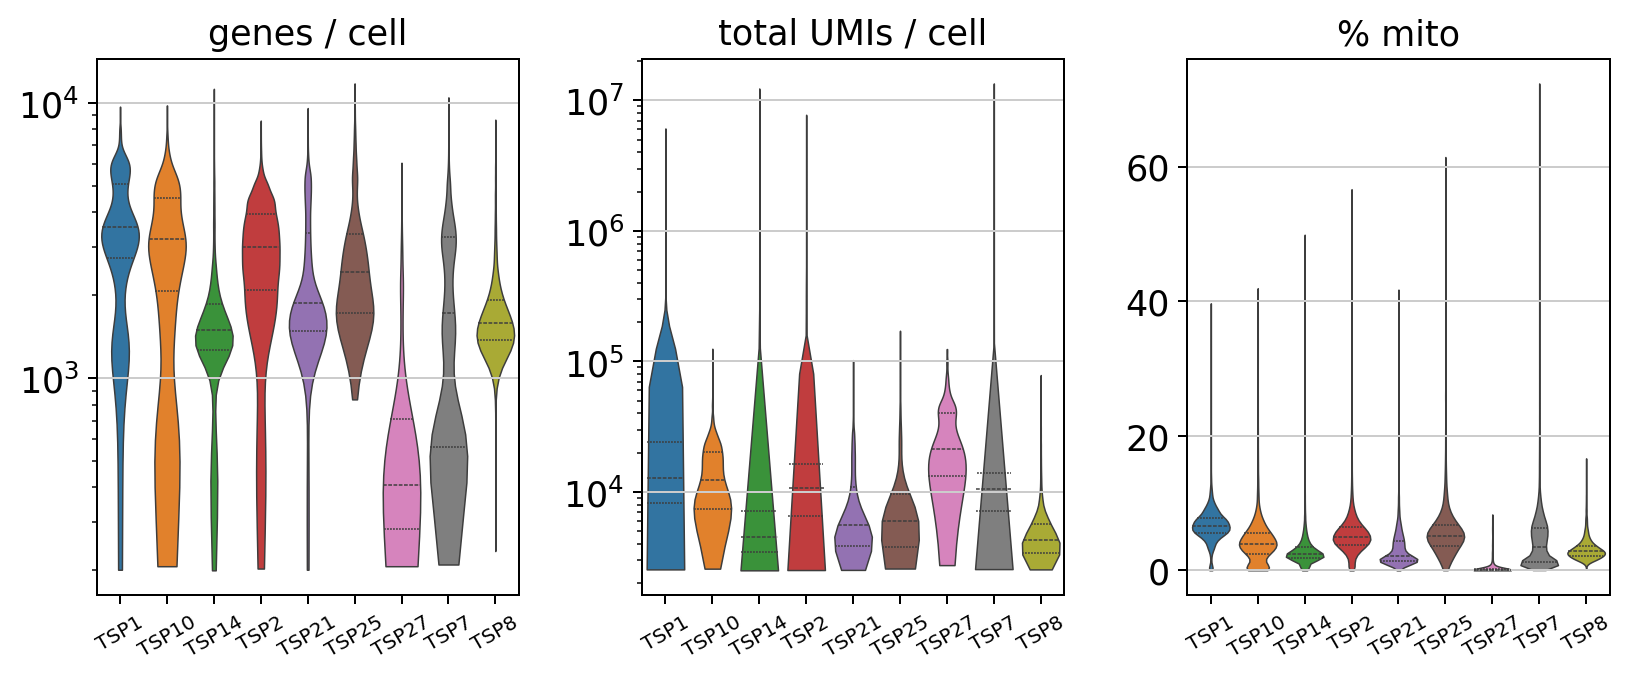

In [6]:
# QC violin plots, grouped by donor.
# `donor_id` comes back from the census as a pandas Categorical that still
# carries all donor levels from the parent dataset, even ones with zero
# cells in this slice — drop unused categories so the x-axis shows only
# the donors actually present.
obs_qc = adata.obs.copy()
obs_qc["donor_id"] = obs_qc["donor_id"].astype("category").cat.remove_unused_categories()
donors = obs_qc["donor_id"].cat.categories.tolist()

fig, axes = plt.subplots(1, 3, figsize=(3 + 0.7 * len(donors), 4), sharex=True)
for ax, col, title, ylog in zip(
    axes,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    ["genes / cell", "total UMIs / cell", "% mito"],
    [True, True, False],
):
    sns.violinplot(
        data=obs_qc, x="donor_id", y=col, order=donors,
        ax=ax, inner="quartile", density_norm="width", cut=0,
        linewidth=0.6, hue="donor_id", legend=False, palette="tab10",
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    if ylog:
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 6. Filter cells and genes

Both filters operate on backed data without materializing. `filter_genes`
sets a column projection that propagates through the rest of the
pipeline (PCA reads only the retained genes).


In [8]:
n_obs_0, n_vars_0 = adata.shape
accel.filter_cells(adata, min_genes=500, max_genes=6000)
accel.filter_cells(adata, max_counts=50_000)
accel.filter_genes(adata, min_cells=10)

# Drop cells with >20% mito.
keep = adata.obs["pct_counts_mt"].to_numpy() < 20
accel.subset_obs(adata, keep)

print(f"cells: {n_obs_0:>6,} -> {adata.n_obs:>6,}")
print(f"genes: {n_vars_0:>6,} -> {adata.n_vars:>6,}")


cells: 85,233 -> 74,840
genes: 61,497 -> 36,887


## 7. Highly variable genes (seurat_v3, raw counts)

We run `seurat_v3` HVG on the **raw counts** (`subset=True` updates the
column projection so all downstream ops — normalize, log1p, PCA — run on
the HVG subset only). Batch-aware HVG uses `donor_id`.


In [9]:
t0 = time.time()
# HVG selection. Some census slices hit loess singularity with batch-aware
# seurat_v3, so try that first and fall back to global seurat_v3 (no batch)
# and finally to the "seurat" flavor on log-normalized counts.
try:
    accel.highly_variable_genes(
        adata,
        n_top_genes=3000,
        flavor="seurat_v3",
        batch_key="donor_id",
        subset=True,
    )
except Exception as exc:
    print(f"batch-aware seurat_v3 HVG failed ({exc}); retrying without batch_key")
    accel.highly_variable_genes(
        adata,
        n_top_genes=3000,
        flavor="seurat_v3",
        subset=True,
    )
print(f"HVG selected {adata.n_vars} genes in {time.time() - t0:.1f}s")

# A compact table of the top HVGs by normalized variance.
hvg_df = adata.var.sort_values("variances_norm", ascending=False).head(15)
hvg_cols = [c for c in ("means", "variances", "variances_norm", "highly_variable_nbatches") if c in hvg_df.columns]
hvg_df[hvg_cols].round(3)

batch-aware seurat_v3 HVG failed (b'There are other near singularities as well. 0.090619'); retrying without batch_key
HVG selected 3000 genes in 26.2s


,means,variances,variances_norm
gene_symbol,,,
IGF2R,19.024,68246.394,77.408
IGHA1,2.647,5525.607,52.819
IGKC,6.761,37052.564,47.530
JCHAIN,1.032,434.160,45.644
DEFA3,0.791,270.420,34.412
IGLC2,2.889,13100.875,30.690
IGHG2,0.195,50.008,29.130
DEFA1,0.375,60.777,26.176
IGHG1,0.222,77.771,24.145


## 8. Normalize + log1p (lazy / fused)

Both transforms are **lazy**: `adata.X` becomes an
`ScxLazyTransformedDataset` that applies `log1p(x * 1e4 / row_sum + 1)`
on-the-fly during slicing. The combination is fused into a single
shard-streaming pass at PCA time.


In [10]:
accel.normalize_total(adata, target_sum=1e4)
accel.log1p(adata)
print("X type:", type(adata.X).__name__)


X type: ScxLazyTransformedDataset


## 9. PCA

`pyscx.accel.pca` runs **streaming randomized SVD** on the lazy
log-normalized matrix. Output lands in `adata.obsm["X_pca"]` /
`adata.varm["PCs"]` in the same shape scanpy produces.


In [11]:
t0 = time.time()
accel.pca(adata, n_comps=50, random_state=0)
print(f"PCA finished in {time.time() - t0:.1f}s")
print("X_pca shape:", adata.obsm["X_pca"].shape)


PCA finished in 29.4s
X_pca shape: (74840, 50)


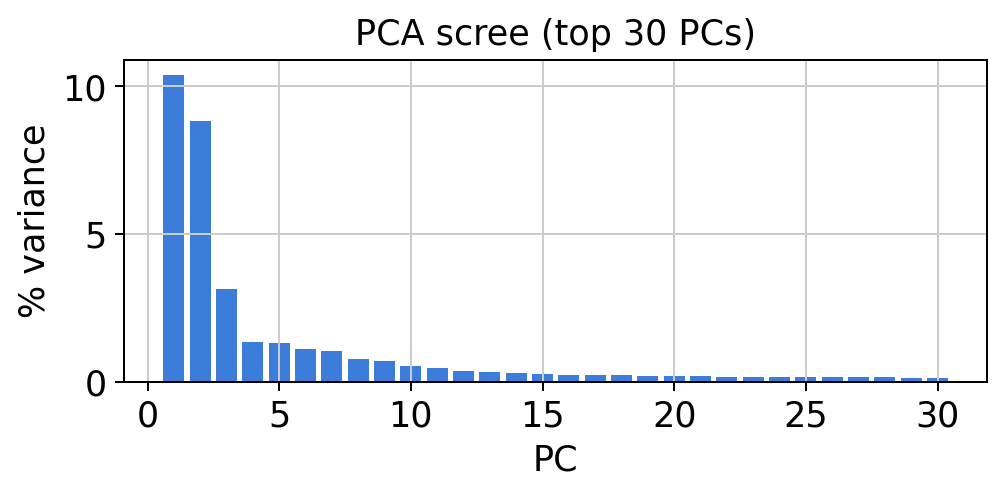

In [12]:
# Variance-explained scree plot (first 30 PCs).
var_ratio = adata.uns["pca"]["variance_ratio"][:30]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, len(var_ratio) + 1), var_ratio * 100, color="#3b7dd8")
ax.set_xlabel("PC")
ax.set_ylabel("% variance")
ax.set_title("PCA scree (top 30 PCs)")
plt.tight_layout()
plt.show()


## 10. Neighbors + UMAP *before* Harmony

We compute a kNN graph and UMAP on the raw PCA — this is the
"uncorrected" reference we'll compare against after Harmony.


In [13]:
t0 = time.time()
accel.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=0)
accel.umap(adata, random_state=0, n_epochs=60)
# Stash the pre-harmony UMAP so we can plot it side-by-side later.
adata.obsm["X_umap_preharmony"] = adata.obsm["X_umap"].copy()
print(f"neighbors + UMAP in {time.time() - t0:.1f}s")


neighbors + UMAP in 40.3s


## 11. Harmony2 batch integration

The pyscx Rust port of [Harmony2][paper] corrects PCA embeddings for
batch effects. We use `donor_id + assay` as the batch covariates and
write the corrected embedding to `adata.obsm["X_pca_harmony"]` so we can
diff it against the uncorrected `X_pca`.

[paper]: https://www.nature.com/articles/s41592-019-0619-0


In [14]:
t0 = time.time()
accel.harmony_integrate(
    adata,
    key=["donor_id", "assay"],
    basis="X_pca",
    adjusted_basis="X_pca_harmony",
    random_state=0,
)
print(f"Harmony finished in {time.time() - t0:.1f}s")
print("X_pca_harmony shape:", adata.obsm["X_pca_harmony"].shape)


Harmony finished in 17.2s
X_pca_harmony shape: (74840, 50)


## 12. Neighbors + UMAP *after* Harmony


In [15]:
t0 = time.time()
accel.neighbors(
    adata, n_neighbors=15, use_rep="X_pca_harmony", random_state=0,
)
accel.umap(adata, random_state=0, n_epochs=60)
print(f"post-harmony neighbors + UMAP in {time.time() - t0:.1f}s")


post-harmony neighbors + UMAP in 50.0s


## 13. Compare pre- / post-Harmony UMAPs

The pre-Harmony plot shows donor-driven separation. Post-Harmony,
shared cell types mix across donors while cell-type structure remains.


plotting 20,000 / 74,840 cells


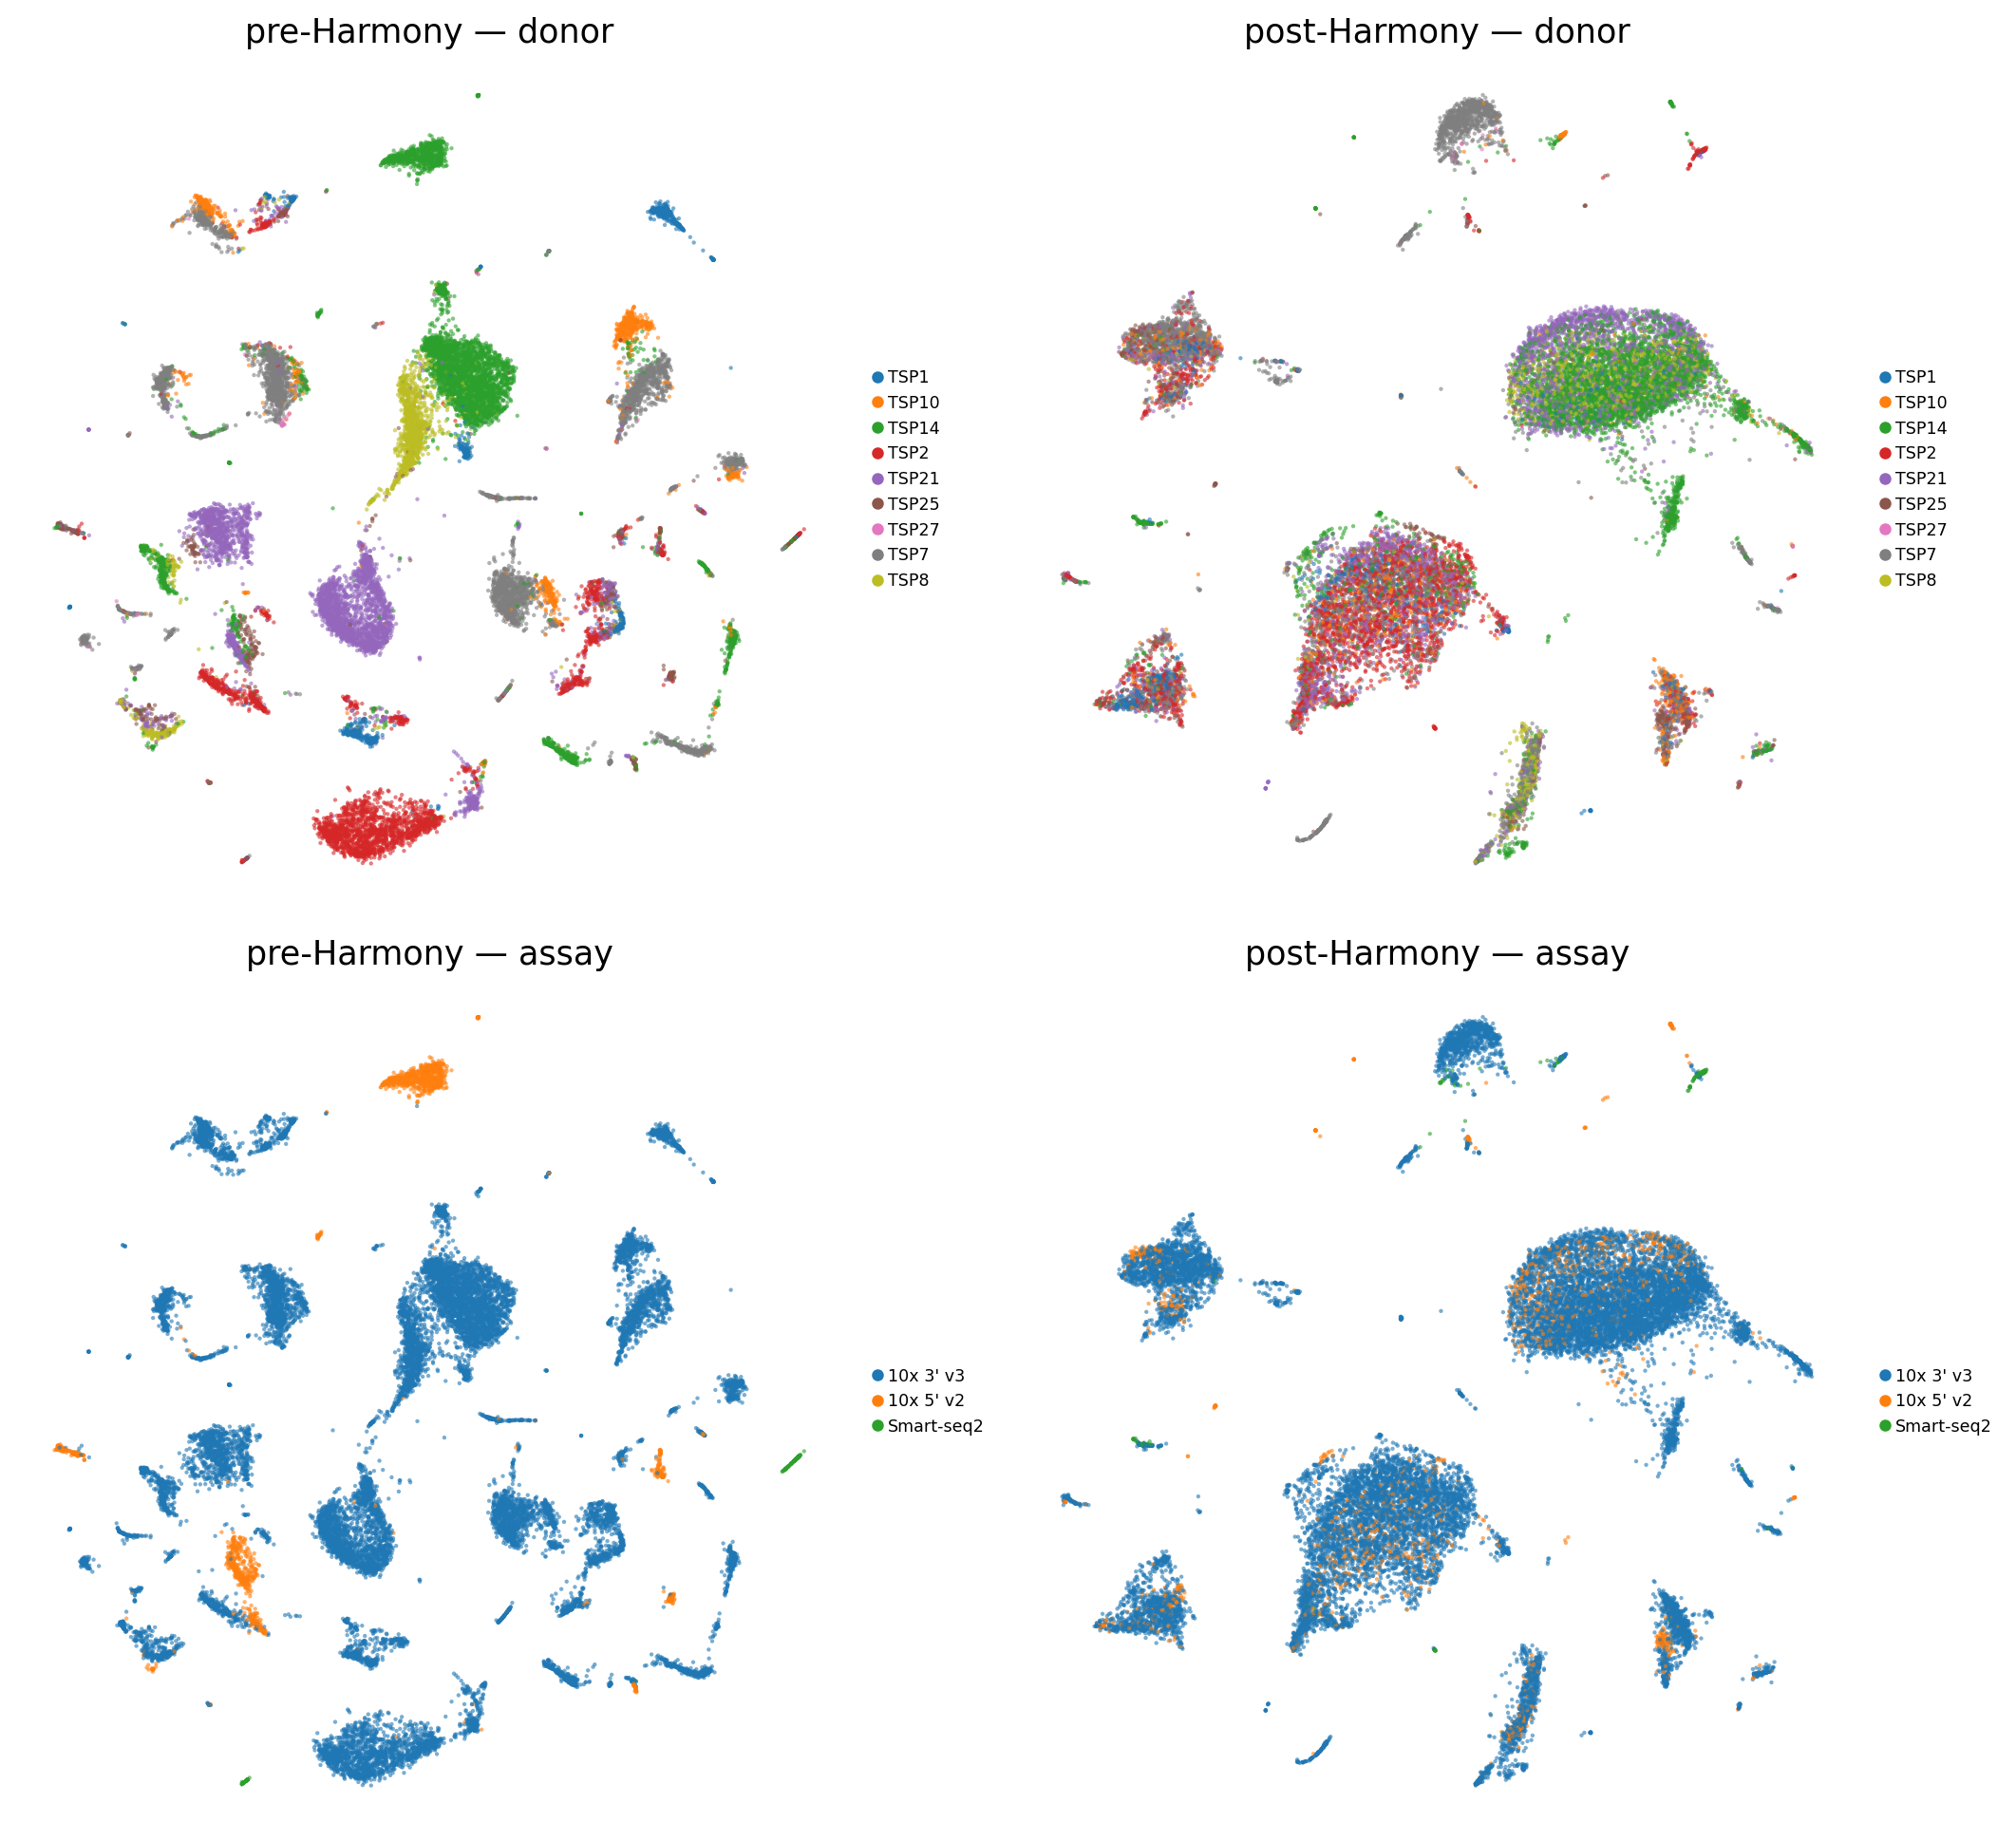

In [16]:
from matplotlib.lines import Line2D


# Subsample for plotting — scatter of ~75k points × multiple panels becomes
# a rendering bottleneck in matplotlib. 20 k points is plenty for conveying
# cluster structure and legend colors.
PLOT_MAX_POINTS = 20_000
_rng = np.random.default_rng(0)
_plot_idx = _rng.choice(adata.n_obs,
                        size=min(PLOT_MAX_POINTS, adata.n_obs),
                        replace=False)
_plot_idx.sort()


def _scatter_cat(ax, coords, labels, title, legend_ncol=1, legend_fontsize=7):
    """Scatter a subsample of points colored by categorical labels."""
    cats = pd.Categorical(np.asarray(labels)[_plot_idx])
    codes = cats.codes
    n_cat = len(cats.categories)
    palette = sns.color_palette("tab20", n_cat) if n_cat > 10 else sns.color_palette("tab10", n_cat)
    cmap = plt.matplotlib.colors.ListedColormap(palette)
    # Shuffle so no single category sits on top.
    order = _rng.permutation(len(codes))
    ax.scatter(
        coords[_plot_idx, 0][order], coords[_plot_idx, 1][order],
        c=codes[order], cmap=cmap, vmin=-0.5, vmax=n_cat - 0.5,
        s=3, alpha=0.6, linewidths=0,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markersize=4, color=palette[i], label=str(cat))
        for i, cat in enumerate(cats.categories)
    ]
    ax.legend(
        handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
        fontsize=legend_fontsize, frameon=False, ncol=legend_ncol,
    )


print(f"plotting {len(_plot_idx):,} / {adata.n_obs:,} cells")

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
_scatter_cat(axes[0, 0], adata.obsm["X_umap_preharmony"],
             adata.obs["donor_id"].values, "pre-Harmony \u2014 donor",
             legend_ncol=1)
_scatter_cat(axes[0, 1], adata.obsm["X_umap"],
             adata.obs["donor_id"].values, "post-Harmony \u2014 donor",
             legend_ncol=1)
_scatter_cat(axes[1, 0], adata.obsm["X_umap_preharmony"],
             adata.obs["assay"].values, "pre-Harmony \u2014 assay")
_scatter_cat(axes[1, 1], adata.obsm["X_umap"],
             adata.obs["assay"].values, "post-Harmony \u2014 assay")
plt.tight_layout()
plt.show()

## 14. Leiden clustering (on the Harmony graph)


In [17]:
t0 = time.time()
accel.leiden(adata, resolution=0.8, random_state=0)
print(f"leiden finished in {time.time() - t0:.1f}s")
print("clusters:", adata.obs["leiden"].nunique())


leiden finished in 3.6s
clusters: 19


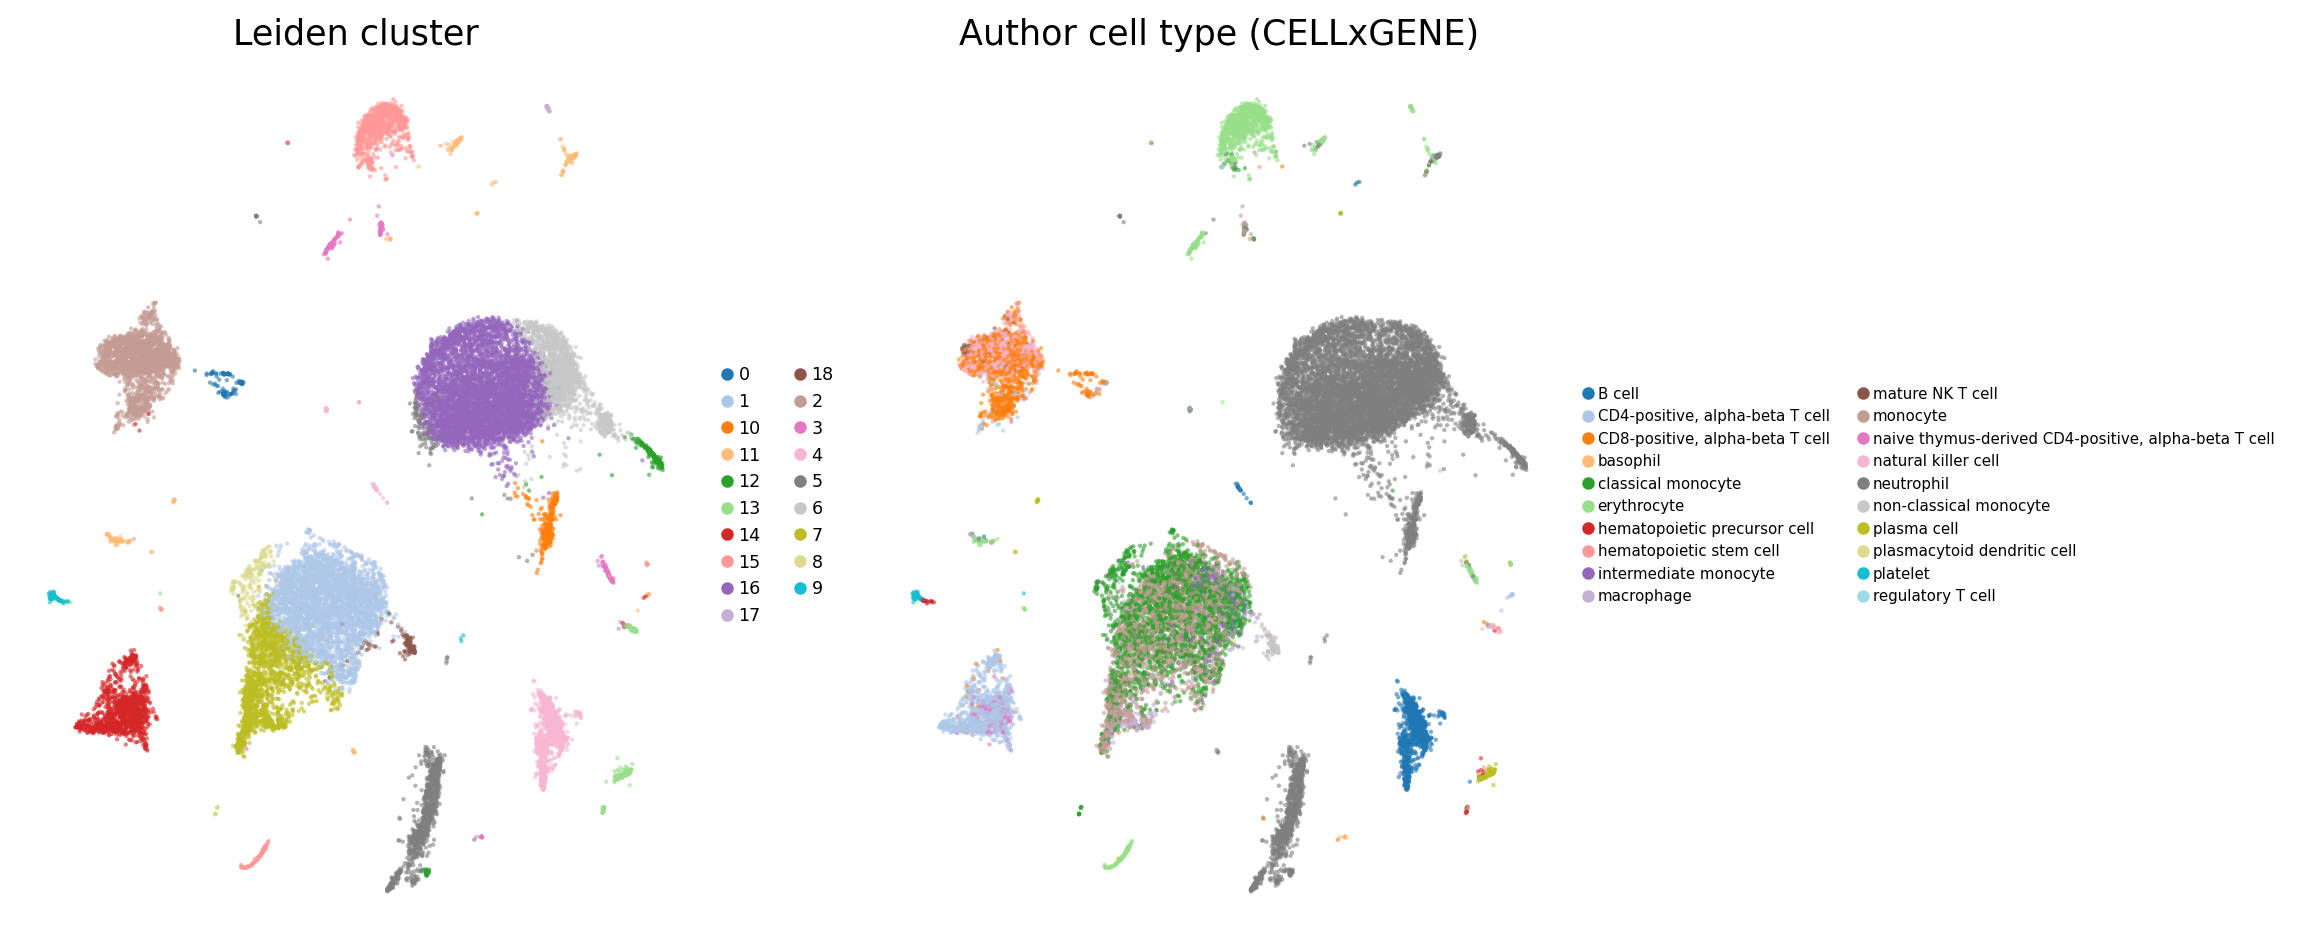

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
_scatter_cat(axes[0], adata.obsm["X_umap"],
             adata.obs["leiden"].values, "Leiden cluster", legend_ncol=2)
# cell_type can carry unused categories after subsetting; drop them for clarity.
ct = adata.obs["cell_type"].astype(str).values
_scatter_cat(axes[1], adata.obsm["X_umap"], ct,
             "Author cell type (CELLxGENE)", legend_ncol=2, legend_fontsize=6)
plt.tight_layout()
plt.show()

## 15. Differential expression (Wilcoxon)

`pyscx.accel.rank_genes_groups` is a streaming Wilcoxon rank-sum DE
test — ranks each gene once across all cells and reuses the ranks
across groups, so it runs in time roughly linear in `n_cells × n_genes`
rather than `n_cells × n_genes × n_groups`.


In [21]:
# For DE, materialize the log-normalized HVG matrix (74k × 3k fits in ~200 MB).
# `accel.rank_genes_groups` walks X linearly and does not currently support the
# lazy-transform wrapper, so we drop to an in-memory AnnData with the same obs/var.
t0 = time.time()
X_mat = adata.X.tocsr()
print(f"materialized {X_mat.shape} (nnz={X_mat.nnz:,}) in {time.time()-t0:.1f}s")

adata_mem = ad.AnnData(
    X=X_mat,
    obs=adata.obs.copy(),
    var=adata.var.copy(),
    obsm=dict(adata.obsm),
)

t0 = time.time()
accel.rank_genes_groups(adata_mem, groupby="leiden", method="wilcoxon")
print(f"DE finished in {time.time()-t0:.1f}s")

# Top 5 marker genes per cluster as a tidy table.
rgg = adata_mem.uns["rank_genes_groups"]
groups = rgg["names"].dtype.names
top_markers = pd.concat([
    pd.DataFrame({
        "cluster": g,
        "rank": np.arange(5),
        "names": rgg["names"][g][:5],
        "scores": rgg["scores"][g][:5],
        "logfoldchanges": rgg["logfoldchanges"][g][:5],
        "pvals_adj": rgg["pvals_adj"][g][:5],
    })
    for g in groups
], ignore_index=True)
top_markers[["cluster", "names", "scores", "logfoldchanges", "pvals_adj"]].round(3).head(30)

materialized (74840, 3000) (nnz=24,597,246) in 7.9s
DE finished in 4.8s


,cluster,names,scores,logfoldchanges,pvals_adj
0,0,CD247,27.126,2.488,0.0
1,0,CD69,21.812,2.105,0.0
2,0,GNLY,20.120,2.485,0.0
3,0,NKG7,19.112,1.896,0.0
4,0,HCST,18.059,1.098,0.0
5,1,VCAN,162.380,2.768,0.0
6,1,LYZ,160.205,1.647,0.0
7,1,CTSD,147.049,1.456,0.0
8,1,RNASE2,143.351,3.034,0.0
9,1,FMN1,143.231,2.635,0.0


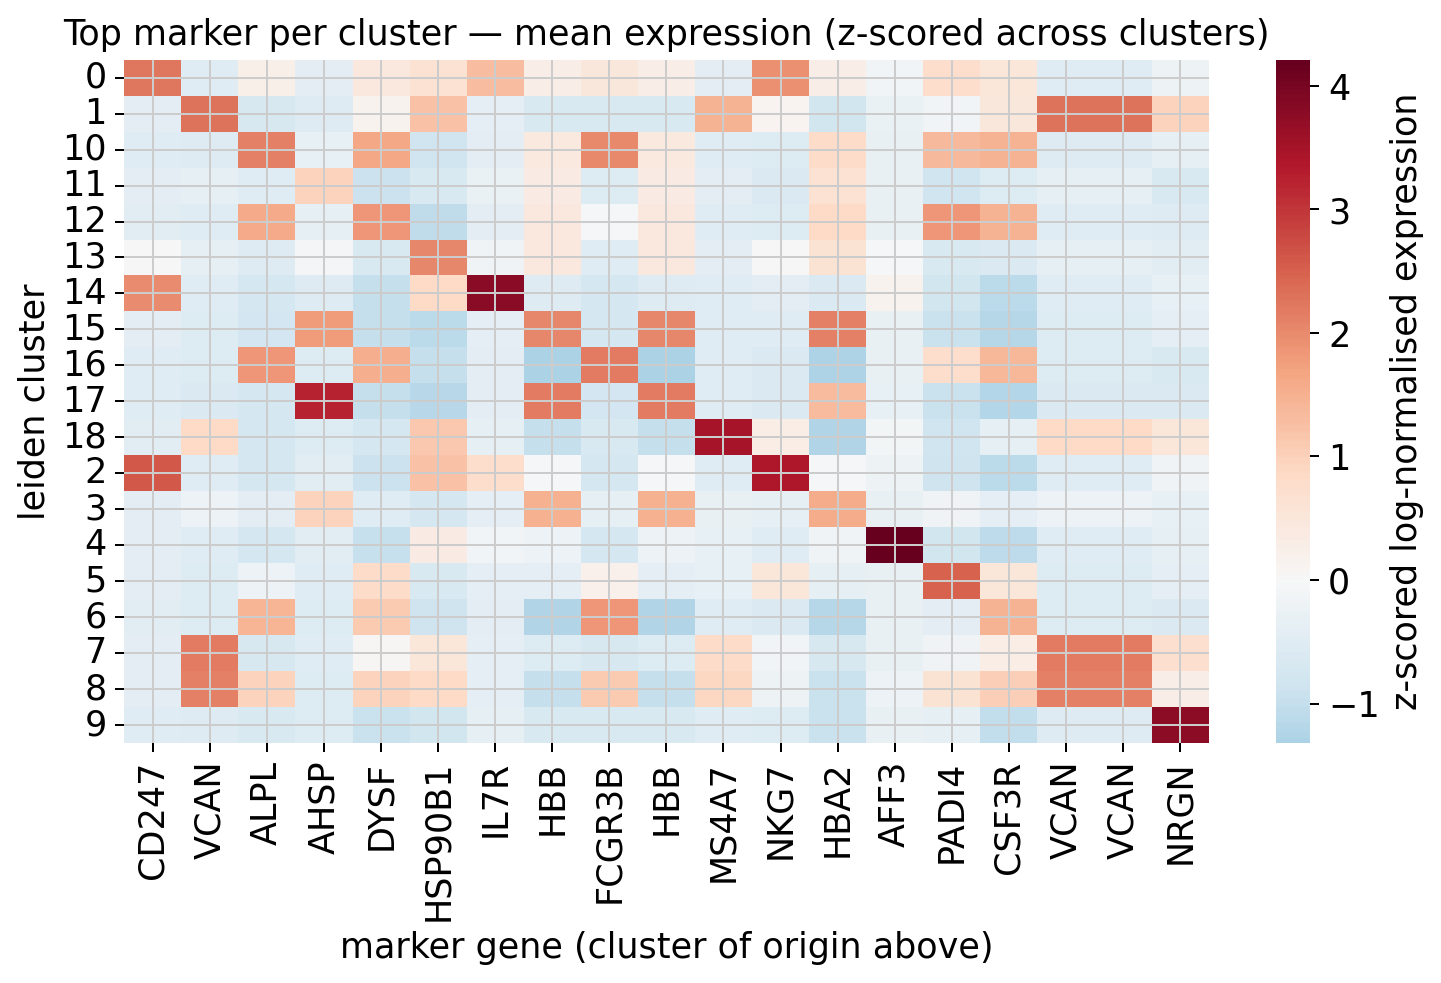

In [22]:
# Visualise the top gene per cluster as a heatmap of z-scored mean log-normalised
# expression across clusters.
top1 = (
    top_markers.drop_duplicates("cluster", keep="first")
    .set_index("cluster")["names"]
)
gene_idx = [adata_mem.var_names.get_loc(g) for g in top1.values]
mat_top = adata_mem.X[:, gene_idx].toarray()
df = pd.DataFrame(mat_top, columns=top1.values)
df["cluster"] = adata_mem.obs["leiden"].values
mean_by_cluster = df.groupby("cluster", observed=True).mean()
zs = (mean_by_cluster - mean_by_cluster.mean()) / (mean_by_cluster.std(ddof=0) + 1e-9)

fig, ax = plt.subplots(figsize=(max(6, len(top1) * 0.45), max(4, len(zs) * 0.3)))
sns.heatmap(
    zs, cmap="RdBu_r", center=0, ax=ax,
    cbar_kws={"label": "z-scored log-normalised expression"},
    xticklabels=True, yticklabels=True,
)
ax.set_title("Top marker per cluster — mean expression (z-scored across clusters)")
ax.set_xlabel("marker gene (cluster of origin above)")
ax.set_ylabel("leiden cluster")
plt.tight_layout()
plt.show()

## 16. Cleanup

Deletes the scratch directory. Comment out the second line if you want
to keep the intermediates for re-running the notebook without
redownloading.


In [23]:
# Release backed file handles before deleting the directory.
for obj_name in ("adata", "adata_mem", "adata_de", "exp", "exp_raw"):
    obj = globals().get(obj_name)
    if obj is not None:
        try:
            obj.file.close()
        except Exception:
            pass
        globals().pop(obj_name, None)

print(f"removing {TMPDIR} ...")
shutil.rmtree(TMPDIR, ignore_errors=True)
print("done.")

removing /home/nickyoungblut/dev/rust/scx/tmp ...
done.
